# Monitoring Deep Neural Network Training with TensorFlow

Training a neural network isn't a "press go and wait" activity. A model can look fine on paper - reasonable architecture, sensible loss function - and still fail silently: gradients vanish in early layers, weights blow up, the learning rate stalls the model in a bad region, or the model overfits classes unevenly

In [172]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


## Data: Credit Card Fraud Detection

We use the ULB/Kaggle credit card fraud dataset, hosted directly by TensorFlow at `storage.googleapis.com` and pulled with `tf.keras.utils.get_file` (about 144MB, cached locally after the first download). It's ~285,000 real, anonymized European card transactions, each described by `Time`, `Amount`, and 28 PCA-derived features (`V1`-`V28`), labeled `Class` (1 = fraud).

Only 492 transactions — about 0.17% — are fraudulent, which makes this dataset the natural home for **class-specific performance**: a model that predicts "not fraud" for every single transaction is already 99.8% accurate, so accuracy alone tells us almost nothing about whether the model actually works.

We split chronologically by `Time` rather than randomly — train on the earliest 70% of transactions, validate on the next 15%, and hold out the most recent 15% as a test set. This mirrors how a fraud model is actually deployed (trained on the past, scored on the future) and gives us a natural reference window to build on for the drift-detection section later.

In [173]:
csv_path = tf.keras.utils.get_file(
    "creditcard.csv",
    "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv",
)
df = pd.read_csv(csv_path)

feature_cols = [c for c in df.columns if c != "Class"]
class_names = ["Legitimate", "Fraud"]

# transactions are already ordered by Time -- split chronologically, as a deployed
# fraud model would be trained (on the past) and scored (on the future)
n = len(df)
train_end, val_end = int(n * 0.7), int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

x_train = train_df[feature_cols].to_numpy(dtype="float32")
y_train = train_df["Class"].to_numpy(dtype="float32")
x_val = val_df[feature_cols].to_numpy(dtype="float32")
y_val = val_df["Class"].to_numpy(dtype="float32")
x_test = test_df[feature_cols].to_numpy(dtype="float32")
y_test = test_df["Class"].to_numpy(dtype="float32")
n_train = len(x_train)

print("train:", x_train.shape, "val:", x_val.shape, "test:", x_test.shape)
print(f"fraud rate -- train: {y_train.mean():.4%}, val: {y_val.mean():.4%}, test: {y_test.mean():.4%}")

train: (199364, 30) val: (42721, 30) test: (42722, 30)
fraud rate -- train: 0.1926%, val: 0.1311%, test: 0.1217%


### A closer look at the data

| column | description |
|---|---|
| `Time` | seconds elapsed between this transaction and the first transaction in the dataset (the data spans about 48 hours) |
| `V1`-`V28` | principal components from a PCA transform of the original (undisclosed) transaction features -- the bank anonymized these for confidentiality, so individually they carry no direct real-world meaning |
| `Amount` | transaction amount |
| `Class` | target label: `1` = fraud, `0` = legitimate |

There are no missing values. `V1`-`V28` are already roughly zero-mean, unit-variance by construction of PCA, while `Time` and `Amount` sit on very different, much larger scales -- which is exactly why the `Normalization` layer in the model below matters.

In [174]:
df.info()
print()
display(df[["Time", "Amount", "V1", "V2", "V3", "Class"]].describe().T.round(2))

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.86,47488.15,0.00,54201.50,84692.00,139320.50,172792.00
Amount,284807.0,88.35,250.12,0.00,5.60,22.00,77.16,25691.16
V1,284807.0,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V2,284807.0,0.00,1.65,-72.72,-0.60,0.07,0.80,22.06
V3,284807.0,-0.00,1.52,-48.33,-0.89,0.18,1.03,9.38
Class,284807.0,0.00,0.04,0.00,0.00,0.00,0.00,1.00


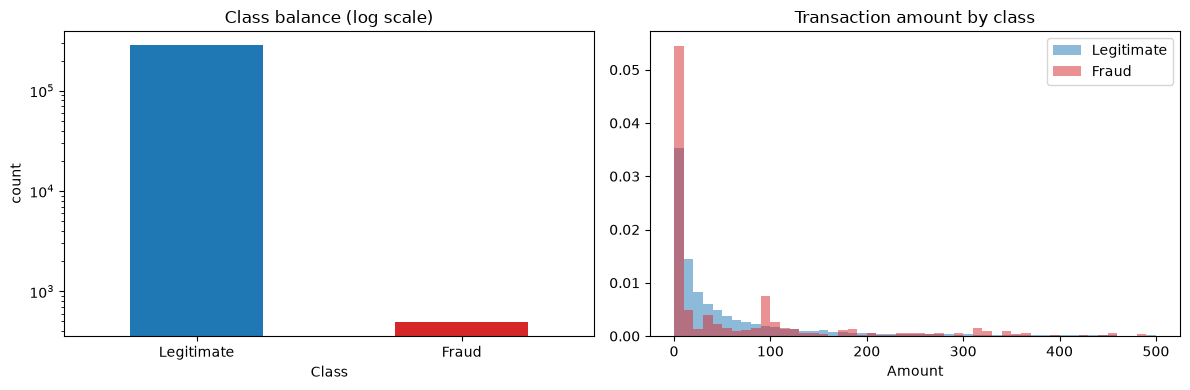

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Class"].value_counts().rename(index={0: "Legitimate", 1: "Fraud"}).plot.bar(
    ax=axes[0], color=["tab:blue", "tab:red"]
)
axes[0].set_yscale("log")
axes[0].set_title("Class balance (log scale)")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=0)

for cls, label, color in [(0, "Legitimate", "tab:blue"), (1, "Fraud", "tab:red")]:
    axes[1].hist(
        df.loc[df["Class"] == cls, "Amount"], bins=50, range=(0, 500),
        density=True, alpha=0.5, label=label, color=color,
    )
axes[1].set_title("Transaction amount by class")
axes[1].set_xlabel("Amount")
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Architecture

A plain fully-connected (dense) network for tabular input: a `Normalization` layer (fit only on the training set) standardizes the 30 numeric features, followed by two dense hidden layers and a single sigmoid output for the fraud / not-fraud decision. Layers are given explicit names so the monitoring callbacks below can refer to them directly.

In [176]:
x_train.shape[1]

30

In [177]:
norm_layer = tf.keras.layers.Normalization(name="normalize",trainable=False)
norm_layer.adapt(x_train)

model1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    norm_layer,
    tf.keras.layers.Dense(64, activation="relu", name="dense1"),
    tf.keras.layers.Dense(32, activation="relu", name="dense2"),
    tf.keras.layers.Dense(1, activation="sigmoid", name="predictions"),
])

model1.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalize (Normalization)       │ (None, 30)             │            61 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,158 (16.25 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 61 (248.00 B)

In [178]:

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy,
    metrics=[
        # "accuracy",
        # tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        # tf.keras.metrics.MeanSquaredError()
    ],
)

In [179]:
history = model1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=32,
    batch_size=1024,
    verbose=2,
)

Epoch 1/32
195/195 - 4s - 18ms/step - loss: 0.0581 - recall: 0.3229 - val_loss: 0.0058 - val_recall: 0.2679
Epoch 2/32
195/195 - 1s - 5ms/step - loss: 0.0053 - recall: 0.7318 - val_loss: 0.0036 - val_recall: 0.5357
Epoch 3/32
195/195 - 1s - 4ms/step - loss: 0.0040 - recall: 0.7708 - val_loss: 0.0029 - val_recall: 0.6071
Epoch 4/32
195/195 - 1s - 5ms/step - loss: 0.0035 - recall: 0.7786 - val_loss: 0.0025 - val_recall: 0.6964
Epoch 5/32
195/195 - 1s - 5ms/step - loss: 0.0032 - recall: 0.7943 - val_loss: 0.0023 - val_recall: 0.7143
Epoch 6/32
195/195 - 1s - 6ms/step - loss: 0.0030 - recall: 0.8073 - val_loss: 0.0022 - val_recall: 0.7143
Epoch 7/32
195/195 - 1s - 4ms/step - loss: 0.0028 - recall: 0.8073 - val_loss: 0.0021 - val_recall: 0.7321
Epoch 8/32
195/195 - 1s - 5ms/step - loss: 0.0027 - recall: 0.8099 - val_loss: 0.0021 - val_recall: 0.7321
Epoch 9/32
195/195 - 1s - 6ms/step - loss: 0.0026 - recall: 0.8125 - val_loss: 0.0021 - val_recall: 0.7321
Epoch 10/32
195/195 - 2s - 9ms/step 

## Callbacks for Training Monitoring

A Keras **callback** is just an object with hooks that Keras invokes at specific points in the training loop. They're the standard mechanism for monitoring: instead of modifying the training loop itself, we attach small, focused observers to it -- Keras calls the relevant method, we read whatever state we need off `self.model` and `logs`, and the training loop continues none the wiser.

`tf.keras.callbacks.Callback` exposes hooks around three different calls, each with a `_begin`/`_end` pair at both the whole-call and the per-batch level:

| hook | fires... |
|---|---|
| `on_train_begin(logs)` | once, before the first epoch of `fit()` |
| `on_epoch_begin(epoch, logs)` | at the start of each epoch |
| `on_train_batch_begin(batch, logs)` | before each training step |
| `on_train_batch_end(batch, logs)` | after each training step -- `logs` carries that step's metrics |
| `on_epoch_end(epoch, logs)` | at the end of each epoch -- `logs` carries that epoch's metrics (`loss`, `val_loss`, `accuracy`, ...) |
| `on_train_end(logs)` | once, after the last epoch of `fit()` (or after early stopping cuts it short) |
| `on_test_begin(logs)` / `on_test_end(logs)` | around a call to `evaluate()`, and around the validation pass inside `fit()` |
| `on_test_batch_begin(batch, logs)` / `on_test_batch_end(batch, logs)` | around each batch of that evaluation pass |
| `on_predict_begin(logs)` / `on_predict_end(logs)` | around a call to `predict()` |
| `on_predict_batch_begin(batch, logs)` / `on_predict_batch_end(batch, logs)` | around each batch of that prediction pass |

(`on_batch_begin`/`on_batch_end` still work too, as aliases for the `on_train_batch_*` pair, kept for backwards compatibility.)

We only need epoch-level granularity for the monitoring below, so the three custom callbacks we write only override `on_epoch_end` (plus `on_train_begin`/`on_epoch_begin` where a timer needs a starting point). The batch-level hooks matter when you need finer resolution -- e.g. logging gradient norms every step instead of every epoch -- and the test/predict hooks matter for monitoring a model *after* training, such as auditing what `evaluate()` or `predict()` see once a model is serving traffic.

Below we write three custom callbacks — for gradient flow, weight distributions, and epoch timing — plus use two of Keras's built-in callbacks (`EarlyStopping`, `ReduceLROnPlateau`) and a small tracker for the learning rate they produce.

In [180]:
class GradientFlowCallback(tf.keras.callbacks.Callback):
    '''Records the L2 norm of the gradient for each named layer's kernel, every epoch,
    computed on one fixed validation batch so the numbers are comparable across epochs.

    Layers are matched by variable identity (layer.kernel) rather than by variable
    name -- Keras 3 no longer prefixes variable names with their owning layer's scope,
    so e.g. every Dense layer's kernel is literally named "kernel".'''

    def __init__(self, x_probe, y_probe, loss_fn, layer_names):
        super().__init__()
        self.x_probe = x_probe
        self.y_probe = y_probe
        self.loss_fn = loss_fn
        self.layer_names = layer_names
        self.history = {name: [] for name in layer_names}

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            preds = self.model(self.x_probe, training=True)
            loss = self.loss_fn(self.y_probe, preds)
        grads = tape.gradient(loss, self.model.trainable_variables)
        grad_by_var_id = {id(v): g for v, g in zip(self.model.trainable_variables, grads)}

        for name in self.layer_names:
            kernel = self.model.get_layer(name).kernel
            grad = grad_by_var_id[id(kernel)]
            self.history[name].append(float(tf.norm(grad).numpy()))

In [181]:
class WeightStatsCallback(tf.keras.callbacks.Callback):
    '''Snapshots the kernel weights of chosen layers at the end of every epoch,
    so we can later look at how their distribution evolves.'''

    def __init__(self, layer_names):
        super().__init__()
        self.layer_names = layer_names
        self.snapshots = {name: [] for name in layer_names}

    def on_epoch_end(self, epoch, logs=None):
        for name in self.layer_names:
            layer = self.model.get_layer(name)
            kernel = layer.get_weights()[0]
            self.snapshots[name].append(kernel.flatten().copy())

In [182]:
class TimeHistoryCallback(tf.keras.callbacks.Callback):
    '''Tracks wall-clock time per epoch -- the basis for computational-efficiency metrics.'''

    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self._epoch_start)

In [183]:
class LearningRateTracker(tf.keras.callbacks.Callback):
    '''Records the optimizer's learning rate at the end of every epoch, so we can see
    how schedulers/plateau-reducers change it over the course of training.'''

    def on_train_begin(self, logs=None):
        self.lr_history = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        self.lr_history.append(float(tf.convert_to_tensor(lr).numpy()))

### Early stopping and learning-rate scheduling

`EarlyStopping` halts training once validation loss stops improving for `patience` epochs, and restores the best weights seen -- this is what protects the run from overfitting past its useful point. `ReduceLROnPlateau` shrinks the learning rate when validation loss plateaus, letting the optimizer take smaller, more careful steps as it approaches a minimum.

These two are far from the only built-in callbacks Keras ships. A few others worth knowing about:

| callback | what it does |
|---|---|
| `ModelCheckpoint` | saves the model (or just its weights) periodically, typically with `save_best_only=True` on a monitored metric -- the standard way to keep the best version of a run on disk even if training later degrades |
| `LearningRateScheduler` | sets the learning rate from a function of the epoch index, for schedules known in advance (step decay, cosine annealing, warmup) rather than reactive ones like `ReduceLROnPlateau` |
| `TensorBoard` | writes logs (scalars, histograms, the model graph) for visualization in TensorBoard -- effectively a ready-made, much more complete version of the custom loss/gradient/weight tracking we build by hand below |
| `CSVLogger` | appends each epoch's metrics as a row to a CSV file, for analysis outside the notebook or process that trained the model |
| `TerminateOnNaN` | stops training immediately if the loss becomes `NaN` or `Inf`, so a diverging run fails fast instead of burning through the remaining epochs |
| `BackupAndRestore` | periodically checkpoints full training state (model, optimizer, epoch) and automatically resumes from it if training is interrupted -- fault tolerance for long-running jobs |
| `LambdaCallback` | wraps arbitrary functions into a callback on the fly, for one-off hooks that don't warrant a full custom class |
| `RemoteMonitor` | streams each epoch's logs as JSON to an HTTP endpoint, for monitoring dashboards that live outside the training process |

We only reach for two of them here (`EarlyStopping`, `ReduceLROnPlateau`), plus the hand-written callbacks above for the metrics Keras doesn't track out of the box.

In [184]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1,
)

## Compiling and Training the Model

Because fraud is ~0.17% of the data, an unweighted loss barely penalizes missing a fraud case -- the optimizer could reach 99.8% training accuracy by ignoring fraud entirely. We counter that with `class_weight`, computed from the training class counts, so a missed fraud costs roughly as much as a false alarm on a legitimate transaction. We also track `precision` and `recall` directly during training, alongside accuracy, since those are what actually matters for this problem.

We then wire all five callbacks (2 built-in, 3 custom) into `model.fit`. `EarlyStopping` and `ReduceLROnPlateau` actively change how training proceeds; the other three passively record what happened, which is what the rest of this notebook visualizes.

In [185]:
norm_layer = tf.keras.layers.Normalization(name="normalize")
norm_layer.adapt(x_train)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    norm_layer,
    # tf.keras.layers.Dense(128, activation="relu", name="dense1"),
    tf.keras.layers.Dense(64, activation="relu", name="dense2"),
    tf.keras.layers.Dense(32, activation="relu", name="dense3"),
    tf.keras.layers.Dense(16, activation="relu", name="dense3"),
    tf.keras.layers.Dense(1, activation="sigmoid", name="predictions"),
])

model.summary()

ValueError: All layers added to a Sequential model should have unique names. Name 'dense3' is already the name of a layer in this model. Update the `name` argument to pass a unique name.

In [ ]:
loss_fn = tf.keras.losses.BinaryCrossentropy()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

n_pos = float(y_train.sum())
n_neg = float(len(y_train) - n_pos)
class_weight = {
    0: (1 / n_neg) * (len(y_train) / 2.0),
    1: (1 / n_pos) * (len(y_train) / 2.0),
}
print("class weights:", class_weight)

class weights: {0: 0.5009649210975977, 1: 259.58854166666663}


In [ ]:
gradient_cb = GradientFlowCallback(
    x_val[:256], y_val[:256].reshape(-1, 1), loss_fn, ["dense1", "dense2", "predictions"]
)
weight_cb = WeightStatsCallback(["dense1", "dense2", "predictions"])
time_cb = TimeHistoryCallback()
lr_cb = LearningRateTracker()

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=1024,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_lr, gradient_cb, weight_cb, time_cb, lr_cb],
    verbose=2,
)

Epoch 1/30
195/195 - 4s - 21ms/step - accuracy: 0.9699 - loss: 0.2266 - precision: 0.0540 - recall: 0.8854 - val_accuracy: 0.9709 - val_loss: 0.1125 - val_precision: 0.0403 - val_recall: 0.9286 - learning_rate: 0.0010
Epoch 2/30
195/195 - 1s - 5ms/step - accuracy: 0.9711 - loss: 0.1411 - precision: 0.0581 - recall: 0.9193 - val_accuracy: 0.9799 - val_loss: 0.0683 - val_precision: 0.0573 - val_recall: 0.9286 - learning_rate: 0.0010
Epoch 3/30
195/195 - 2s - 8ms/step - accuracy: 0.9784 - loss: 0.1064 - precision: 0.0782 - recall: 0.9479 - val_accuracy: 0.9852 - val_loss: 0.0536 - val_precision: 0.0764 - val_recall: 0.9286 - learning_rate: 0.0010
Epoch 4/30
195/195 - 2s - 9ms/step - accuracy: 0.9812 - loss: 0.0841 - precision: 0.0898 - recall: 0.9583 - val_accuracy: 0.9882 - val_loss: 0.0435 - val_precision: 0.0924 - val_recall: 0.9107 - learning_rate: 0.0010
Epoch 5/30
195/195 - 1s - 7ms/step - accuracy: 0.9838 - loss: 0.0648 - precision: 0.1043 - recall: 0.9740 - val_accuracy: 0.9908 - 

## Loss Curves

The most basic monitoring artifact: training vs. validation loss and metrics per epoch. A widening gap between the two loss curves is the classic overfitting signature; a validation curve that plateaus (triggering `ReduceLROnPlateau`/`EarlyStopping` above) tells us the run reached the point of diminishing returns.

With fraud at ~0.17% of the data, accuracy sits close to a flat, uninformative 99.8% line almost immediately -- watch precision and recall instead, since those are the curves that actually show the model learning to separate the two classes.

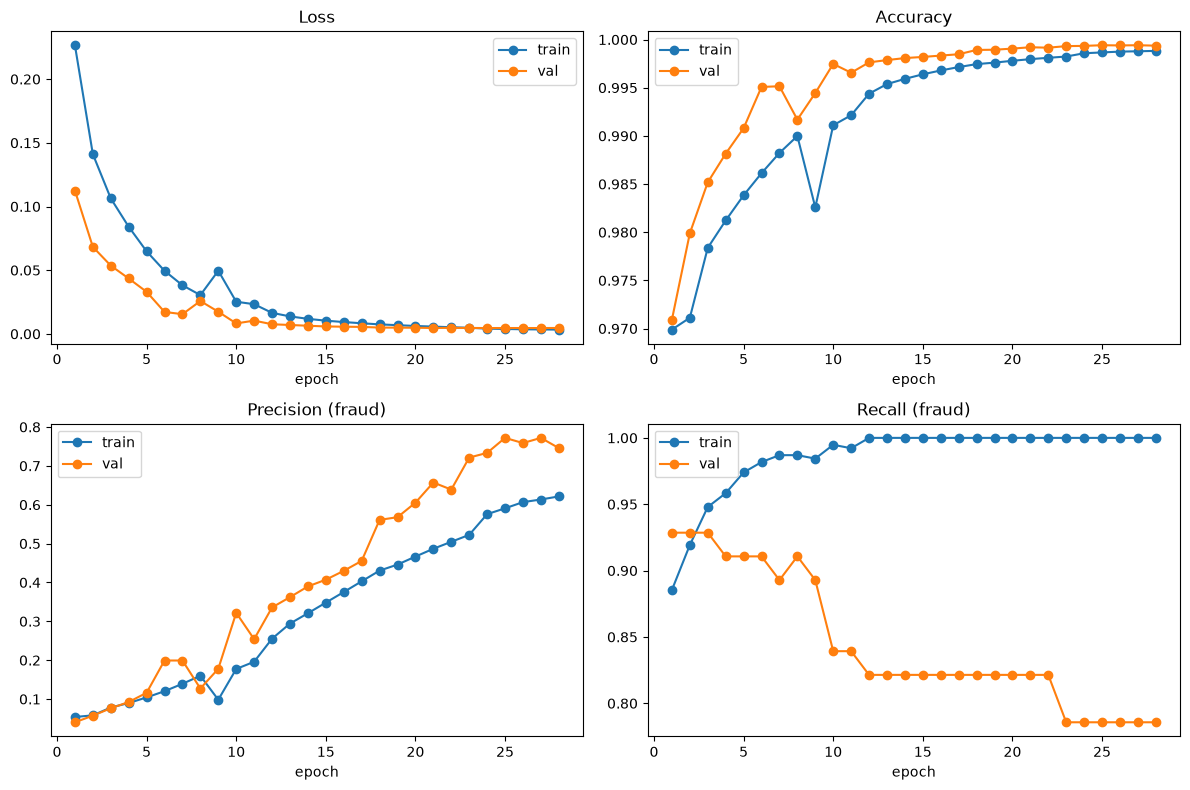

In [ ]:
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(epochs_ran, hist["loss"], marker="o", label="train")
axes[0, 0].plot(epochs_ran, hist["val_loss"], marker="o", label="val")
axes[0, 0].set_title("Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs_ran, hist["accuracy"], marker="o", label="train")
axes[0, 1].plot(epochs_ran, hist["val_accuracy"], marker="o", label="val")
axes[0, 1].set_title("Accuracy")
axes[0, 1].legend()

axes[1, 0].plot(epochs_ran, hist["precision"], marker="o", label="train")
axes[1, 0].plot(epochs_ran, hist["val_precision"], marker="o", label="val")
axes[1, 0].set_title("Precision (fraud)")
axes[1, 0].legend()

axes[1, 1].plot(epochs_ran, hist["recall"], marker="o", label="train")
axes[1, 1].plot(epochs_ran, hist["val_recall"], marker="o", label="val")
axes[1, 1].set_title("Recall (fraud)")
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("epoch")

plt.tight_layout()
plt.show()

## Gradient Flow

During backpropagation, the loss's gradient is propagated layer by layer back to the input. If gradients shrink dramatically as they move toward earlier layers ("vanishing gradients"), those layers barely learn; if they grow instead, training can become unstable ("exploding gradients"). Plotting the gradient norm of each layer, epoch by epoch, makes this directly visible instead of leaving it as a hidden cause behind a bad loss curve.

### A synthetic illustration

Our own model is small and well-behaved, so it won't actually show either pathology -- to see what vanishing and exploding gradients look like, we build three tiny throwaway networks instead. Each is 15 dense hidden layers deep (deep enough for backpropagation to compound through), differing only in activation function and weight-initialization scale. We run one forward/backward pass on random data and plot the resulting gradient norm at every layer:

- **vanishing** -- `sigmoid` activations (derivative capped at 0.25) with a plain initialization: the repeated multiplication by sub-1 terms during backpropagation shrinks the gradient sharply
- **exploding** -- `relu` activations with a deliberately oversized weight initialization: large weight matrices amplify both the forward activations and the backward gradient at every layer they pass through
- **healthy** -- `relu` activations with a variance-preserving ("He") initialization scaled to the layer width -- the standard recipe for keeping signal magnitude roughly stable regardless of depth

What matters here is the gap between the three curves' orders of magnitude, not the exact shape of any one of them -- that gap is the diagnostic signal to watch for in a real model.

vanishing (sigmoid, plain init)    gradient norm range: 0.0212 -- 3.08
healthy (relu, He-scaled init)     gradient norm range: 5.06 -- 29.2
exploding (relu, oversized init)   gradient norm range: 5.3e+06 -- 3e+07


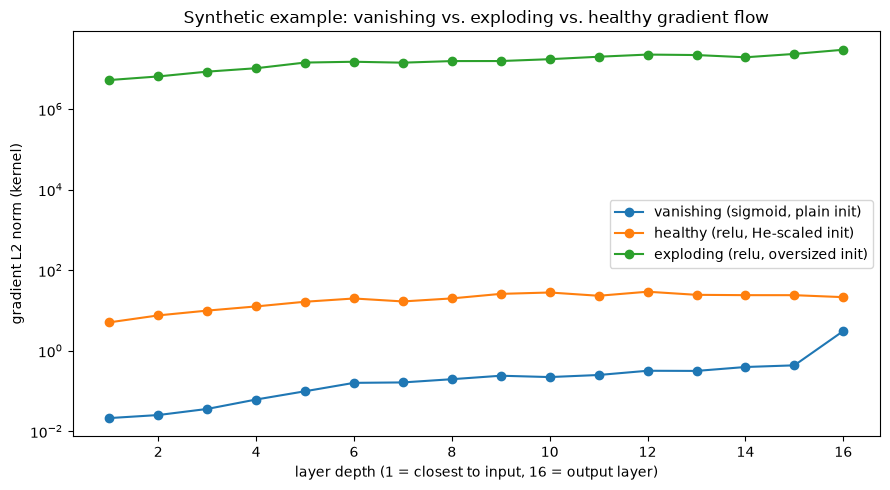

In [ ]:
def make_toy_network(n_layers, activation, init_stddev, width=64):
    layers = [tf.keras.layers.Input(shape=(width,))]
    for i in range(n_layers):
        layers.append(tf.keras.layers.Dense(
            width, activation=activation,
            kernel_initializer=tf.keras.initializers.RandomNormal(stddev=init_stddev),
            name=f"hidden{i}",
        ))
    layers.append(tf.keras.layers.Dense(1, name="output"))
    return tf.keras.Sequential(layers)


def layerwise_gradient_norms(net, x, y):
    with tf.GradientTape() as tape:
        preds = net(x, training=True)
        loss = tf.reduce_mean(tf.keras.losses.mse(y, preds))
    grads = tape.gradient(loss, net.trainable_variables)
    grad_by_id = {id(v): g for v, g in zip(net.trainable_variables, grads)}
    return [
        float(tf.norm(grad_by_id[id(layer.kernel)]).numpy())
        for layer in net.layers if hasattr(layer, "kernel")
    ]


tf.random.set_seed(0)
x_toy = tf.random.normal((64, 64))
y_toy = tf.random.uniform((64, 1))

scenarios = {
    "vanishing (sigmoid, plain init)": make_toy_network(15, "sigmoid", 1.0),
    "healthy (relu, He-scaled init)": make_toy_network(15, "relu", (2 / 64) ** 0.5),
    "exploding (relu, oversized init)": make_toy_network(15, "relu", 0.3),
}

fig, ax = plt.subplots(figsize=(9, 5))
for label, net in scenarios.items():
    norms = layerwise_gradient_norms(net, x_toy, y_toy)
    ax.plot(range(1, len(norms) + 1), norms, marker="o", label=label)
    print(f"{label:34s} gradient norm range: {min(norms):.3g} -- {max(norms):.3g}")

ax.set_yscale("log")
ax.set_xlabel("layer depth (1 = closest to input, 16 = output layer)")
ax.set_ylabel("gradient L2 norm (kernel)")
ax.set_title("Synthetic example: vanishing vs. exploding vs. healthy gradient flow")
ax.legend()
plt.tight_layout()
plt.show()

### Back to our own model

With that as a reference, here's what gradient flow actually looks like for the fraud-detection model above, epoch by epoch. Two hidden layers, ReLU activations, and normalized inputs are exactly the ingredients that keep a network out of the vanishing/exploding regime, so we'd expect these curves to stay in a comparatively narrow, stable band rather than tracking off toward either extreme above.

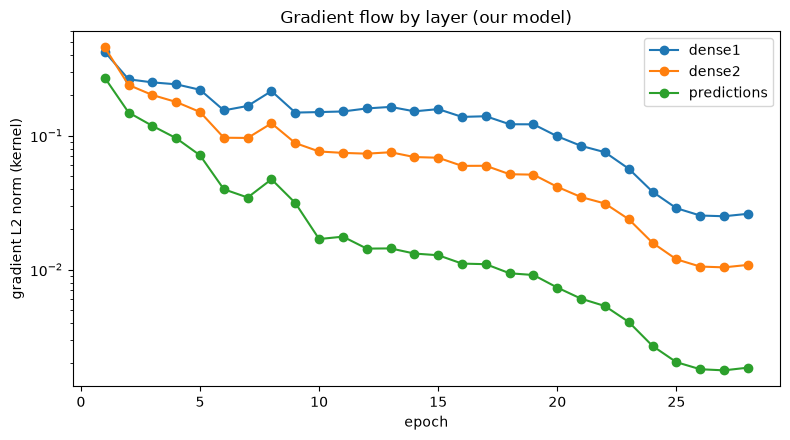

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for layer_name, norms in gradient_cb.history.items():
    ax.plot(epochs_ran, norms, marker="o", label=layer_name)

ax.set_xlabel("epoch")
ax.set_ylabel("gradient L2 norm (kernel)")
ax.set_title("Gradient flow by layer (our model)")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

## Weight Distribution

Gradients tell us how weights are being *pushed*; weight distributions tell us where they *end up*. Comparing the kernel-weight histogram of a layer at the first vs. the last recorded epoch shows whether the layer's weights spread out (learning meaningful structure) or stay collapsed near zero (a sign the layer isn't contributing much, often the downstream symptom of vanishing gradients).

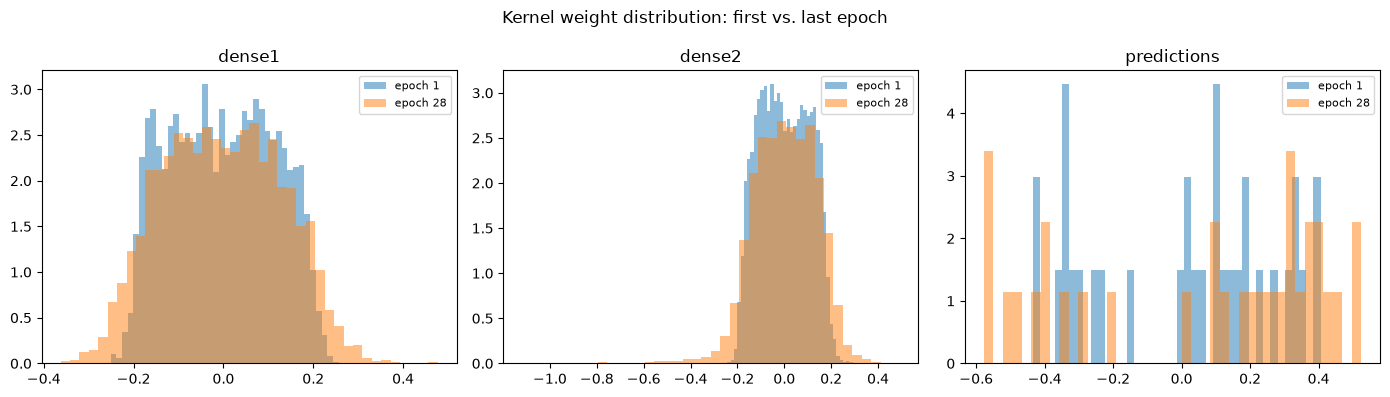

In [ ]:
fig, axes = plt.subplots(1, len(weight_cb.layer_names), figsize=(14, 4), sharey=False)

for ax, name in zip(axes, weight_cb.layer_names):
    snaps = weight_cb.snapshots[name]
    ax.hist(snaps[0], bins=40, alpha=0.5, label="epoch 1", density=True)
    ax.hist(snaps[-1], bins=40, alpha=0.5, label=f"epoch {len(snaps)}", density=True)
    ax.set_title(name)
    ax.legend(fontsize=8)

fig.suptitle("Kernel weight distribution: first vs. last epoch")
plt.tight_layout()
plt.show()

## Learning Rate Dynamics

`ReduceLROnPlateau` is itself a monitor: it watches validation loss and cuts the learning rate when progress stalls. Plotting the LR trajectory alongside the loss curve shows *when* those cuts happened and lets us sanity-check that each cut actually coincides with a plateau, rather than firing arbitrarily.

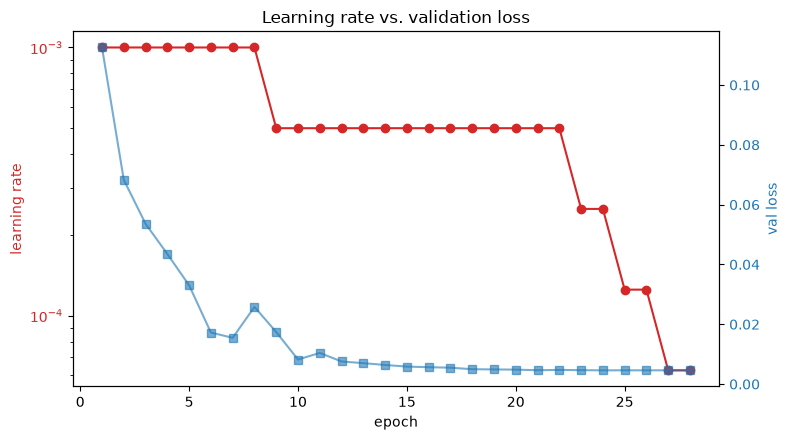

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(epochs_ran, lr_cb.lr_history, color="tab:red", marker="o")
ax1.set_xlabel("epoch")
ax1.set_ylabel("learning rate", color="tab:red")
ax1.set_yscale("log")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(epochs_ran, hist["val_loss"], color="tab:blue", marker="s", alpha=0.6)
ax2.set_ylabel("val loss", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.title("Learning rate vs. validation loss")
plt.tight_layout()
plt.show()

## Computational Efficiency

Model quality is only half the picture in production: how much compute a training run (and later, each inference call) costs shapes what's actually deployable. Here we look at per-epoch wall-clock time, total training time, parameter count, and training throughput.

Total parameters:      14,398
Trainable parameters:  14,337
Epochs run:            28
Total training time:   43.17s
Mean epoch time:       1.54s
Training throughput:   129,312 samples/sec


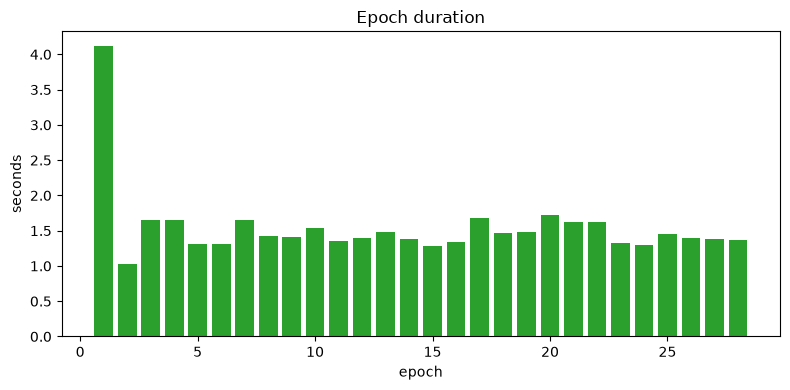

In [ ]:
total_params = model.count_params()
trainable_params = sum(int(tf.size(w)) for w in model.trainable_weights)
total_time = sum(time_cb.epoch_times)
throughput = n_train / np.mean(time_cb.epoch_times)

print(f"Total parameters:      {total_params:,}")
print(f"Trainable parameters:  {trainable_params:,}")
print(f"Epochs run:            {len(time_cb.epoch_times)}")
print(f"Total training time:   {total_time:.2f}s")
print(f"Mean epoch time:       {np.mean(time_cb.epoch_times):.2f}s")
print(f"Training throughput:   {throughput:,.0f} samples/sec")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(epochs_ran, time_cb.epoch_times, color="tab:green")
ax.set_xlabel("epoch")
ax.set_ylabel("seconds")
ax.set_title("Epoch duration")
plt.tight_layout()
plt.show()

## Activation Visualization

Weights describe *how* a layer transforms its input; activations show what it actually *produces* for a real example. We build a second model that shares the trained weights but exposes every hidden layer's output, then feed it one transaction. For a dense network there are no spatial feature maps to plot -- instead we look at each hidden layer's activation vector directly: as a strip of neuron values (which units fired, and how strongly) and as a distribution.

We deliberately pick a fraud transaction from the test set, since that's the harder case a good model has to represent distinctly from the overwhelming majority-class pattern.

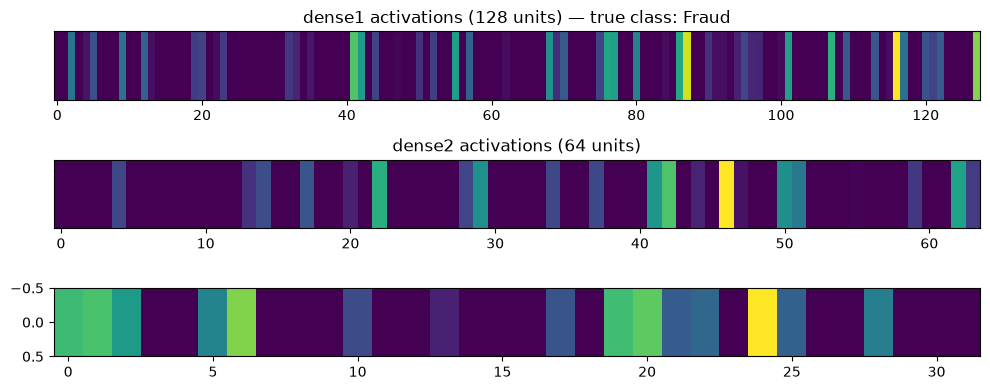

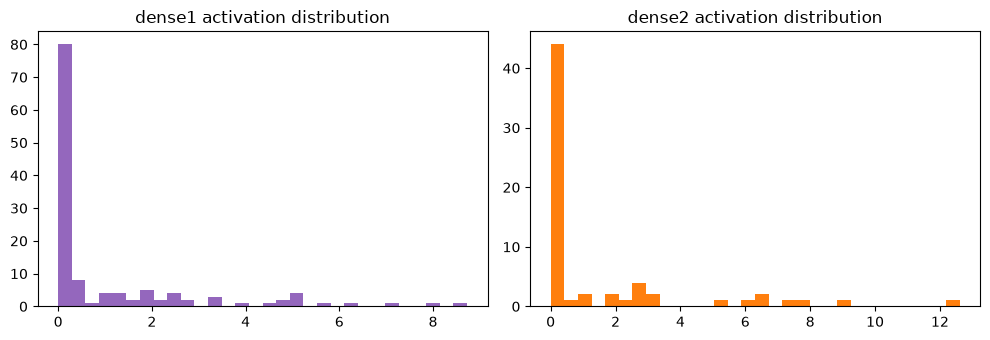

In [189]:
activation_layer_names = ["dense1", "dense2","dense3"]
activation_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.get_layer(name).output for name in activation_layer_names],
)

fraud_idx = np.where(y_test == 1)[0][0]
sample_txn = x_test[fraud_idx:fraud_idx + 1]
dense1_act, dense2_act,dense3_act = activation_model(sample_txn, training=False)

fig, axes = plt.subplots(3, 1, figsize=(10, 4))
axes[0].imshow(dense1_act.numpy(), aspect="auto", cmap="viridis")
axes[0].set_title(f"dense1 activations (128 units) — true class: {class_names[int(y_test[fraud_idx])]}")
axes[0].set_yticks([])
axes[1].imshow(dense2_act.numpy(), aspect="auto", cmap="viridis")
axes[2].imshow(dense3_act.numpy(), aspect="auto", cmap="viridis")
axes[1].set_title("dense2 activations (64 units)")
axes[1].set_yticks([])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(dense1_act.numpy().flatten(), bins=30, color="tab:purple")
axes[0].set_title("dense1 activation distribution")
axes[1].hist(dense2_act.numpy().flatten(), bins=30, color="tab:orange")
axes[1].set_title("dense2 activation distribution")
plt.tight_layout()
plt.show()

## Class-Specific Performance

A single "test accuracy" number is actively misleading here: predicting "legitimate" for every transaction already scores about 99.8%. We compute a confusion matrix with `tf.math.confusion_matrix` and derive per-class precision, recall, and F1 directly from it -- this is where we actually see whether the model catches fraud, and at what cost in false alarms.

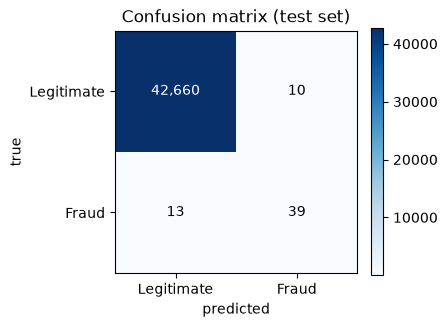

In [ ]:
test_probs = model.predict(x_test, verbose=0).ravel()
test_preds = (test_probs > 0.5).astype(int)

cm = tf.math.confusion_matrix(y_test.astype(int), test_preds, num_classes=2).numpy()

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(2)); ax.set_xticklabels(class_names)
ax.set_yticks(range(2)); ax.set_yticklabels(class_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix (test set)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Overall test accuracy: 0.999



,precision,recall,f1,support
class,,,,
Legitimate,1.000,1.00,1.000,42670
Fraud,0.796,0.75,0.772,52


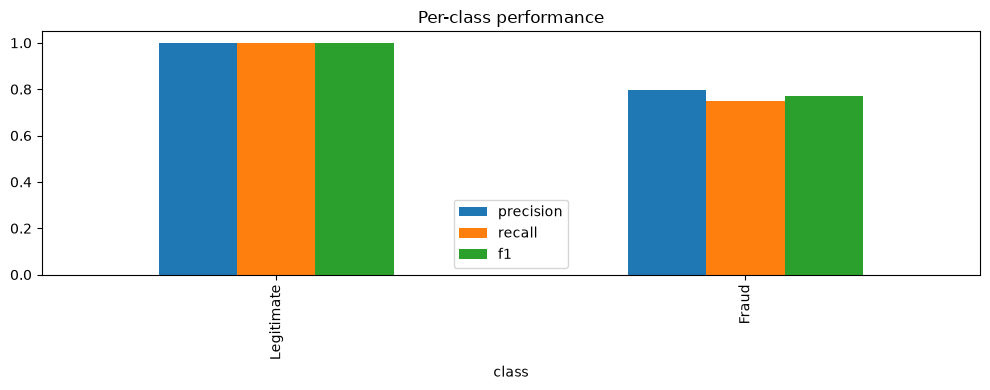

In [ ]:
tp = np.diag(cm).astype(float)
precision = tp / cm.sum(axis=0).clip(min=1)
recall = tp / cm.sum(axis=1).clip(min=1)
f1 = 2 * precision * recall / (precision + recall).clip(min=1e-9)

report = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": cm.sum(axis=1),
}).set_index("class")

overall_acc = tp.sum() / cm.sum()
print(f"Overall test accuracy: {overall_acc:.3f}\n")
display(report.round(3))

report[["precision", "recall", "f1"]].plot.bar(figsize=(10, 4), title="Per-class performance")
plt.tight_layout()
plt.show()

## Drift Detection

Everything above monitors *training*. In production, the question shifts: does the data the model is now seeing still look like the data it was trained on? **Drift detection** compares a statistic of incoming ("production") data against the same statistic on the reference (training/test) distribution, and flags a meaningful divergence.

We simulate drift the way it plausibly happens for a system like this: a shift in the `Amount` distribution (a new merchant category, a currency repricing) plus mild noise across the PCA'd `V`-features (a model/pipeline upstream getting recalibrated), applied to a copy of the test window. We compare two signals between the clean and drifted batches:
- the model's **prediction confidence** (`max(p, 1-p)`, since this is a binary sigmoid output rather than a softmax)
- the **mean dense1 activation** per transaction (a lightweight summary of internal representation)

We quantify the shift with the **Population Stability Index (PSI)**, a standard drift metric: bin the reference distribution into deciles, compare bin proportions between reference and current data, and sum `(cur% - ref%) * ln(cur% / ref%)` across bins. PSI < 0.1 is typically considered stable, 0.1-0.25 a moderate shift worth watching, and > 0.25 a significant drift.

In [ ]:
def population_stability_index(reference, current, n_bins=10, eps=1e-6):
    bin_edges = np.quantile(reference, np.linspace(0, 1, n_bins + 1))
    bin_edges[0], bin_edges[-1] = -np.inf, np.inf

    ref_counts, _ = np.histogram(reference, bins=bin_edges)
    cur_counts, _ = np.histogram(current, bins=bin_edges)

    ref_pct = ref_counts / len(reference) + eps
    cur_pct = cur_counts / len(current) + eps

    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

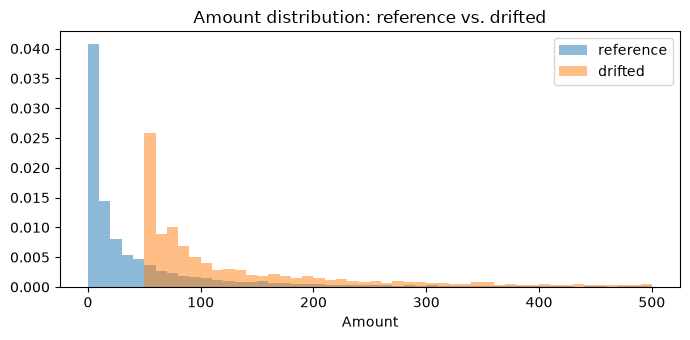

In [ ]:
rng = np.random.default_rng(0)
amount_idx = feature_cols.index("Amount")
v_idxs = [feature_cols.index(c) for c in feature_cols if c.startswith("V")]

x_test_drifted = x_test.copy()
x_test_drifted[:, amount_idx] = x_test_drifted[:, amount_idx] * 3.0 + 50.0
x_test_drifted[:, v_idxs] += rng.normal(0, 0.5, size=(len(x_test_drifted), len(v_idxs))).astype("float32")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(x_test[:, amount_idx], bins=50, range=(0, 500), alpha=0.5, label="reference", density=True)
ax.hist(x_test_drifted[:, amount_idx], bins=50, range=(0, 500), alpha=0.5, label="drifted", density=True)
ax.set_title("Amount distribution: reference vs. drifted")
ax.set_xlabel("Amount")
ax.legend()
plt.tight_layout()
plt.show()

/home/sam/Code/DS Work Notebooks /module_5/venv/lib/python3.12/site-packages/keras/src/models/functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_310']
Received: inputs=Tensor(shape=(42722, 30))
  warnings.warn(msg)


PSI (prediction confidence): 0.009 -> stable
PSI (dense1 mean activation): 0.592 -> significant drift


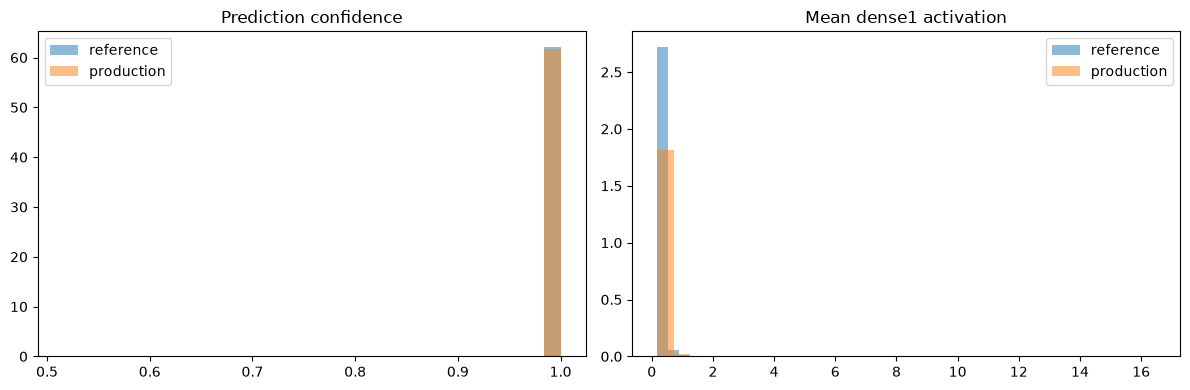

In [ ]:
probs_ref = model.predict(x_test, verbose=0).ravel()
probs_cur = model.predict(x_test_drifted, verbose=0).ravel()

confidence_ref = np.maximum(probs_ref, 1 - probs_ref)
confidence_cur = np.maximum(probs_cur, 1 - probs_cur)

dense1_ref, _ = activation_model(x_test, training=False)
dense1_cur, _ = activation_model(x_test_drifted, training=False)
mean_act_ref = dense1_ref.numpy().mean(axis=1)
mean_act_cur = dense1_cur.numpy().mean(axis=1)

psi_confidence = population_stability_index(confidence_ref, confidence_cur)
psi_activation = population_stability_index(mean_act_ref, mean_act_cur)


def drift_verdict(psi):
    if psi < 0.1:
        return "stable"
    elif psi < 0.25:
        return "moderate shift"
    return "significant drift"


print(f"PSI (prediction confidence): {psi_confidence:.3f} -> {drift_verdict(psi_confidence)}")
print(f"PSI (dense1 mean activation): {psi_activation:.3f} -> {drift_verdict(psi_activation)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(confidence_ref, bins=30, alpha=0.5, label="reference", density=True)
axes[0].hist(confidence_cur, bins=30, alpha=0.5, label="production", density=True)
axes[0].set_title("Prediction confidence")
axes[0].legend()

axes[1].hist(mean_act_ref, bins=30, alpha=0.5, label="reference", density=True)
axes[1].hist(mean_act_cur, bins=30, alpha=0.5, label="production", density=True)
axes[1].set_title("Mean dense1 activation")
axes[1].legend()

plt.tight_layout()
plt.show()